# OWRD Daily Water Level - Depth Below Land Surface

This notebook reads all OWRD daily water level CSV files and plots water level
as depth below land surface on a single figure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [2]:
# Path to downloaded data
data_dir = os.path.join(os.getcwd(), "downloaded")

# Find all OWRD daily WL files
daily_files = sorted(glob.glob(os.path.join(data_dir, "OWRD_*_daily_WL.csv")))
print(f"Found {len(daily_files)} OWRD daily WL files:")
for f in daily_files:
    print(f"  {os.path.basename(f)}")

Found 14 OWRD daily WL files:
  OWRD_UMAT0003879_daily_WL.csv
  OWRD_UMAT0003908_daily_WL.csv
  OWRD_UMAT0003958_daily_WL.csv
  OWRD_UMAT0003963_daily_WL.csv
  OWRD_UMAT0003965_daily_WL.csv
  OWRD_UMAT0005065_daily_WL.csv
  OWRD_UMAT0053833_daily_WL.csv
  OWRD_UMAT0054639_daily_WL.csv
  OWRD_UMAT0058103_daily_WL.csv
  OWRD_UMAT0058119_daily_WL.csv
  OWRD_UMAT0058161_daily_WL.csv
  OWRD_UMAT0058602_daily_WL.csv
  OWRD_UMAT0058603_daily_WL.csv
  OWRD_UMAT0059188_daily_WL.csv


In [3]:
# Read all files into a dictionary keyed by well ID
well_data = {}
for filepath in daily_files:
    df = pd.read_csv(filepath, parse_dates=["date"])
    well_id = df["well_id"].iloc[0]
    well_data[well_id] = df
    print(f"{well_id}: {len(df)} records ({df['date'].min().date()} to {df['date'].max().date()})")

UMAT0003879: 8114 records (2004-04-09 to 2026-06-26)
UMAT0003908: 2075 records (2020-10-21 to 2026-06-26)
UMAT0003958: 6227 records (2009-06-09 to 2026-06-26)
UMAT0003963: 2433 records (2019-10-25 to 2026-06-22)
UMAT0003965: 1338 records (2022-10-28 to 2026-06-26)
UMAT0005065: 1710 records (2021-10-21 to 2026-06-26)
UMAT0053833: 1316 records (2022-04-20 to 2025-11-25)
UMAT0054639: 6841 records (2007-10-04 to 2026-06-26)
UMAT0058103: 1828 records (2021-06-23 to 2026-06-24)
UMAT0058119: 2928 records (2018-06-21 to 2026-06-26)
UMAT0058161: 2906 records (2018-07-13 to 2026-06-26)
UMAT0058602: 1826 records (2021-06-25 to 2026-06-24)
UMAT0058603: 1830 records (2021-06-23 to 2026-06-26)
UMAT0059188: 144 records (2026-02-03 to 2026-06-26)


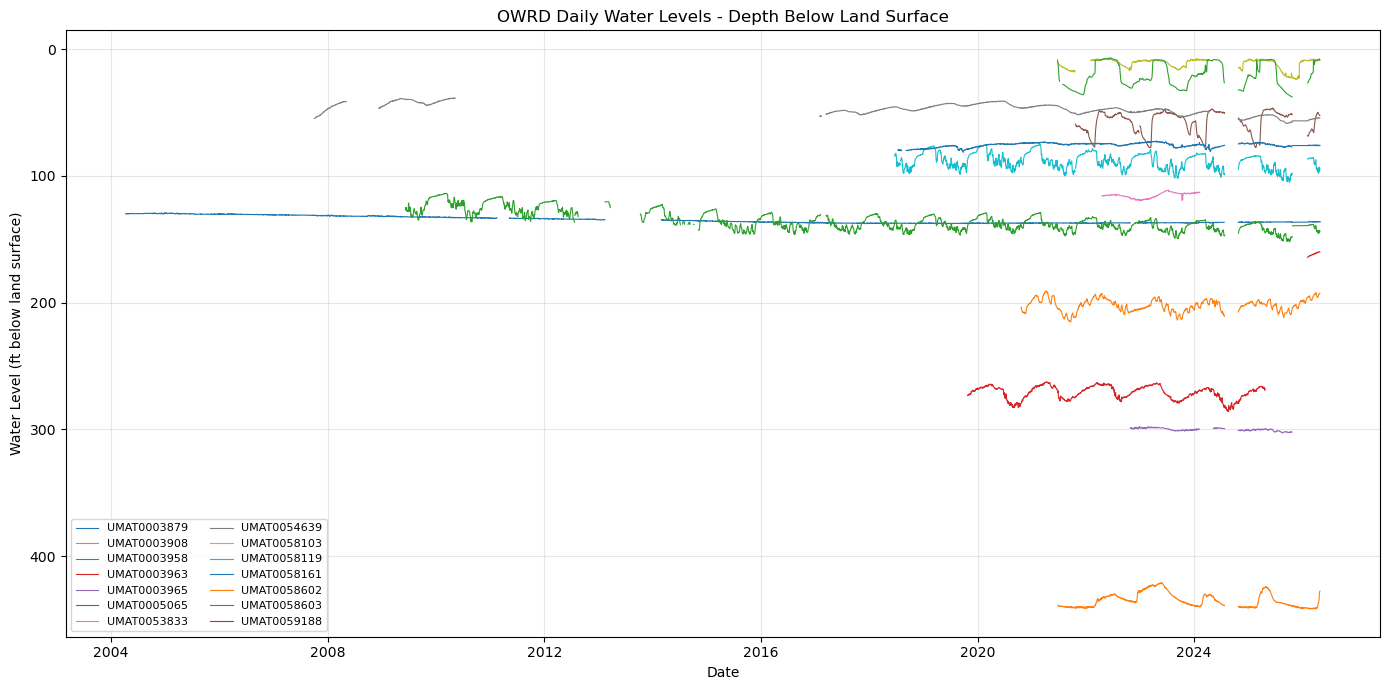

In [4]:
# Plot all wells on one figure
fig, ax = plt.subplots(figsize=(14, 7))

for well_id, df in well_data.items():
    ax.plot(df["date"], df["wl_ft_below_land_surface"], label=well_id, linewidth=0.8)

# Invert y-axis so increasing depth is downward
ax.invert_yaxis()

ax.set_xlabel("Date")
ax.set_ylabel("Water Level (ft below land surface)")
ax.set_title("OWRD Daily Water Levels - Depth Below Land Surface")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()